<h1> Experiment coincidence against photon frequency </h1>

In [2]:
#General imports
resol = 300
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

import sys
import numpy as np
from pathlib import Path
pi = np.pi

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

#Local imports
from experiments.coincidence_vs_frequency import run_coincidence_vs_frequency
from src.bare_param import get_bare_param_n

<h2> Execute the experiment </h2>

To assess the impact of the frequency window, we run the experiment three times. Each experiment corresponds to a given frequency window $[\Lambda_{\rm IR}, \Lambda_{\rm UV}]$

In [4]:
#Parameters of the simulation
L = 50

param_photons_bis = {'delta_k': [0.05*pi, 0.05*pi],
                 'x_0': [-L/4, -L/4]}  #the photon frequency will be varied in this experiment

correction = True
omega_A = 10*pi
gamma_A = 5*pi

param_time_evol = {'T': L/2, 'dt': 0.01}

#Define an array of frequencies around the cavity bare esonance
nb_freq = 15
omega_p_tab = np.linspace(omega_A - 0.8*gamma_A, omega_A + 0.8*gamma_A, nb_freq)

#Assess the curve of reflection vs frequency of different frequency windows

frequency_windows = [(0*pi, 20*pi),
                    (0*pi, 19*pi),
                    (0*pi, 18*pi),
                    (0*pi, 17*pi)]

Run the experiment

In [5]:
for i in [0,1,2,3]:
    index_experiment = i+1
    print("Running frequency window number ", index_experiment, " out of ", len(frequency_windows))
    cutoffs = {'ir_cutoff': frequency_windows[i][0], 'uv_cutoff': frequency_windows[i][1]}

    if correction:
        omega_0, gamma_0 = get_bare_param_n(omega_A, gamma_A, frequency_windows[i][0], frequency_windows[i][1])
    else:
        omega_0, gamma_0 = omega_A, gamma_A

    param_cavity = {'omega_0': omega_0, 'gamma': gamma_0, 'L': L}
    #Run the experiment

    frequency_values, coincidence_tab = run_coincidence_vs_frequency(param_photons_bis, param_cavity, param_time_evol, omega_p_tab, cutoffs, 
                                                                         index_experiment=index_experiment, correction=True)

Running frequency window number  1  out of  4


100%|██████████| 15/15 [26:41<00:00, 106.76s/it]


Running frequency window number  2  out of  4


100%|██████████| 15/15 [22:56<00:00, 91.75s/it]


Running frequency window number  3  out of  4


100%|██████████| 15/15 [19:21<00:00, 77.41s/it]


Running frequency window number  4  out of  4


100%|██████████| 15/15 [17:43<00:00, 70.90s/it]


<h2> Plot the results </h2>

Load the data and plot the results

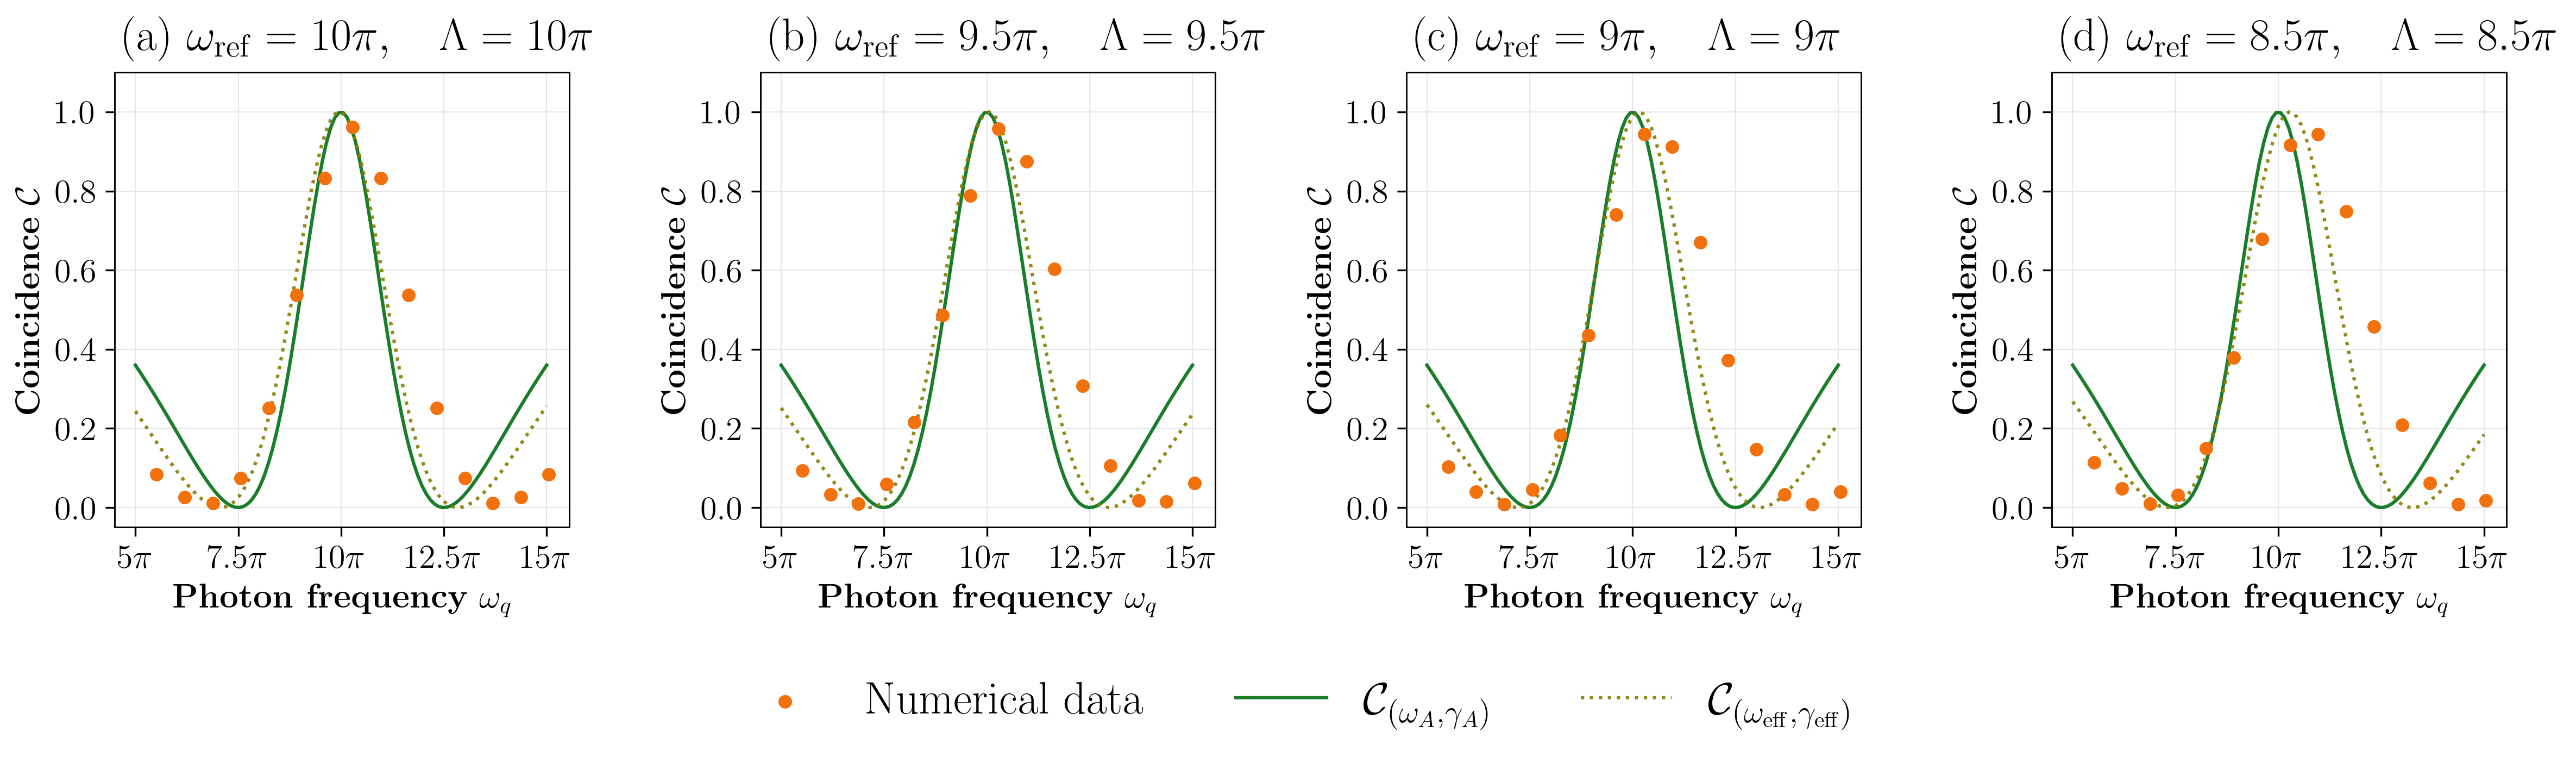

In [6]:
# =========================
# Paramètres
# =========================
index_experiments = [1,2,3,4]

color_atom = "#007013"
color_eff = "#877d00"
color_data = "#f2710f"

subfig_labels = [r'(a) $\omega_{\rm ref} = 10\pi, \quad \Lambda = 10\pi$', 
                 r'(b) $\omega_{\rm ref} = 9.5\pi, \quad \Lambda = 9.5\pi$',
                 r'(c) $\omega_{\rm ref} = 9\pi, \quad \Lambda = 9\pi$',
                 r'(d) $\omega_{\rm ref} = 8.5\pi, \quad \Lambda = 8.5\pi$']

# =========================
# Figure
# =========================
fig, axs = plt.subplots(1,4, figsize=(16,4), dpi=300, sharex=False)
axs = axs.flat

# =========================
# Boucle expériences
# =========================
for idx, ax in enumerate(axs):

    index_experiment = index_experiments[idx]

    ir_cutoff = frequency_windows[index_experiment-1][0]
    uv_cutoff = frequency_windows[index_experiment-1][1]

    data_file = f"../results/csv_files/coincidence_vs_frequency_{index_experiment}.csv"
    df = pd.read_csv(data_file)

    photon_frequency_tab = df['photon_frequency_tab'].to_numpy()
    coincidence_tab = df['final_reflection_tab'].to_numpy()

    frequency_tab_theory = np.linspace(
        param_cavity['omega_0'] - param_cavity['gamma'],
        param_cavity['omega_0'] + param_cavity['gamma'],
        100
    )

    # =========================
    # Bare prediction
    # =========================
    R_theory_bare = 1/(1 + ((frequency_tab_theory - param_cavity['omega_0'])/(param_cavity['gamma']/2))**2)
    coincidence_bare = 1 - 4*R_theory_bare*(1-R_theory_bare)

    # =========================
    # Physical prediction
    # =========================
    prefactor = 1/(1+param_cavity['gamma']/(2*pi)*(1/(ir_cutoff-param_cavity['omega_0']) - 1/(uv_cutoff-param_cavity['omega_0'])))

    omega_A = param_cavity['omega_0'] - param_cavity['gamma']/(2*pi) * np.log((uv_cutoff-param_cavity['omega_0'])/(param_cavity['omega_0']-ir_cutoff)) * prefactor
    Gamma = param_cavity['gamma'] * prefactor

    R_theory_physical = 1/(1 + ((frequency_tab_theory - omega_A)/(Gamma/2))**2)
    coincidence_physical = 1 - 4*R_theory_physical*(1-R_theory_physical)

    # =========================
    # Plot
    # =========================

    ax.scatter(
        photon_frequency_tab,
        coincidence_tab,
        color=color_data,
        s=25,
        label="Numerical data",
        zorder=3
    )

    ax.plot(
        frequency_tab_theory,
        coincidence_bare,
        color=color_atom,
        linewidth=1.5,
        alpha=0.9,
        label=r'$\mathcal{C}_{(\omega_A,\gamma_A)}$'
    )

    ax.plot(
        frequency_tab_theory,
        coincidence_physical,
        color=color_eff,
        linewidth=1.5,
        linestyle=':',
        alpha=0.9,
        label=r'$\mathcal{C}_{(\omega_{\rm eff},\gamma_{\rm eff})}$'
    )

    # =========================
    # Subfigure label
    # =========================
    ax.text(
        0.02,1.05,
        subfig_labels[idx],
        transform=ax.transAxes,
        fontsize=20,
        fontweight='bold'
    )

    # =========================
    # Axes
    # =========================

    ax.set_xlabel(r'\textbf{Photon frequency} $\omega_q$', fontsize=15)

    ax.set_ylabel(r'\textbf{Coincidence} $\mathcal{C}$', fontsize=15)

    ax.set_ylim([-0.05,1.1])

    ax.set_xticks([
        param_cavity['omega_0'] - param_cavity['gamma'],
        param_cavity['omega_0'] - param_cavity['gamma']/2,
        param_cavity['omega_0'],
        param_cavity['omega_0'] + param_cavity['gamma']/2,
        param_cavity['omega_0'] + param_cavity['gamma']
    ])

    ax.set_xticklabels([r"$5\pi$",r"$7.5\pi$",r"$10\pi$",r"$12.5\pi$",r"$15\pi$"])

    ax.grid(color='0.9', linestyle='-', linewidth=0.5)

    ax.tick_params(axis='both', which='major', length=4, width=0.8)

    for item in (ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(15)


# =========================
# Légende commune
# =========================

handles, labels = axs[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5,0),
    ncol=3,
    frameon=False,
    fontsize=20
)

plt.tight_layout()

plt.savefig(
    "../results/fig/coincidence_vs_frequency_multi_experiment.pdf",
    bbox_inches="tight",
    pad_inches=0.2
)

plt.show()

Check the effects of the correction

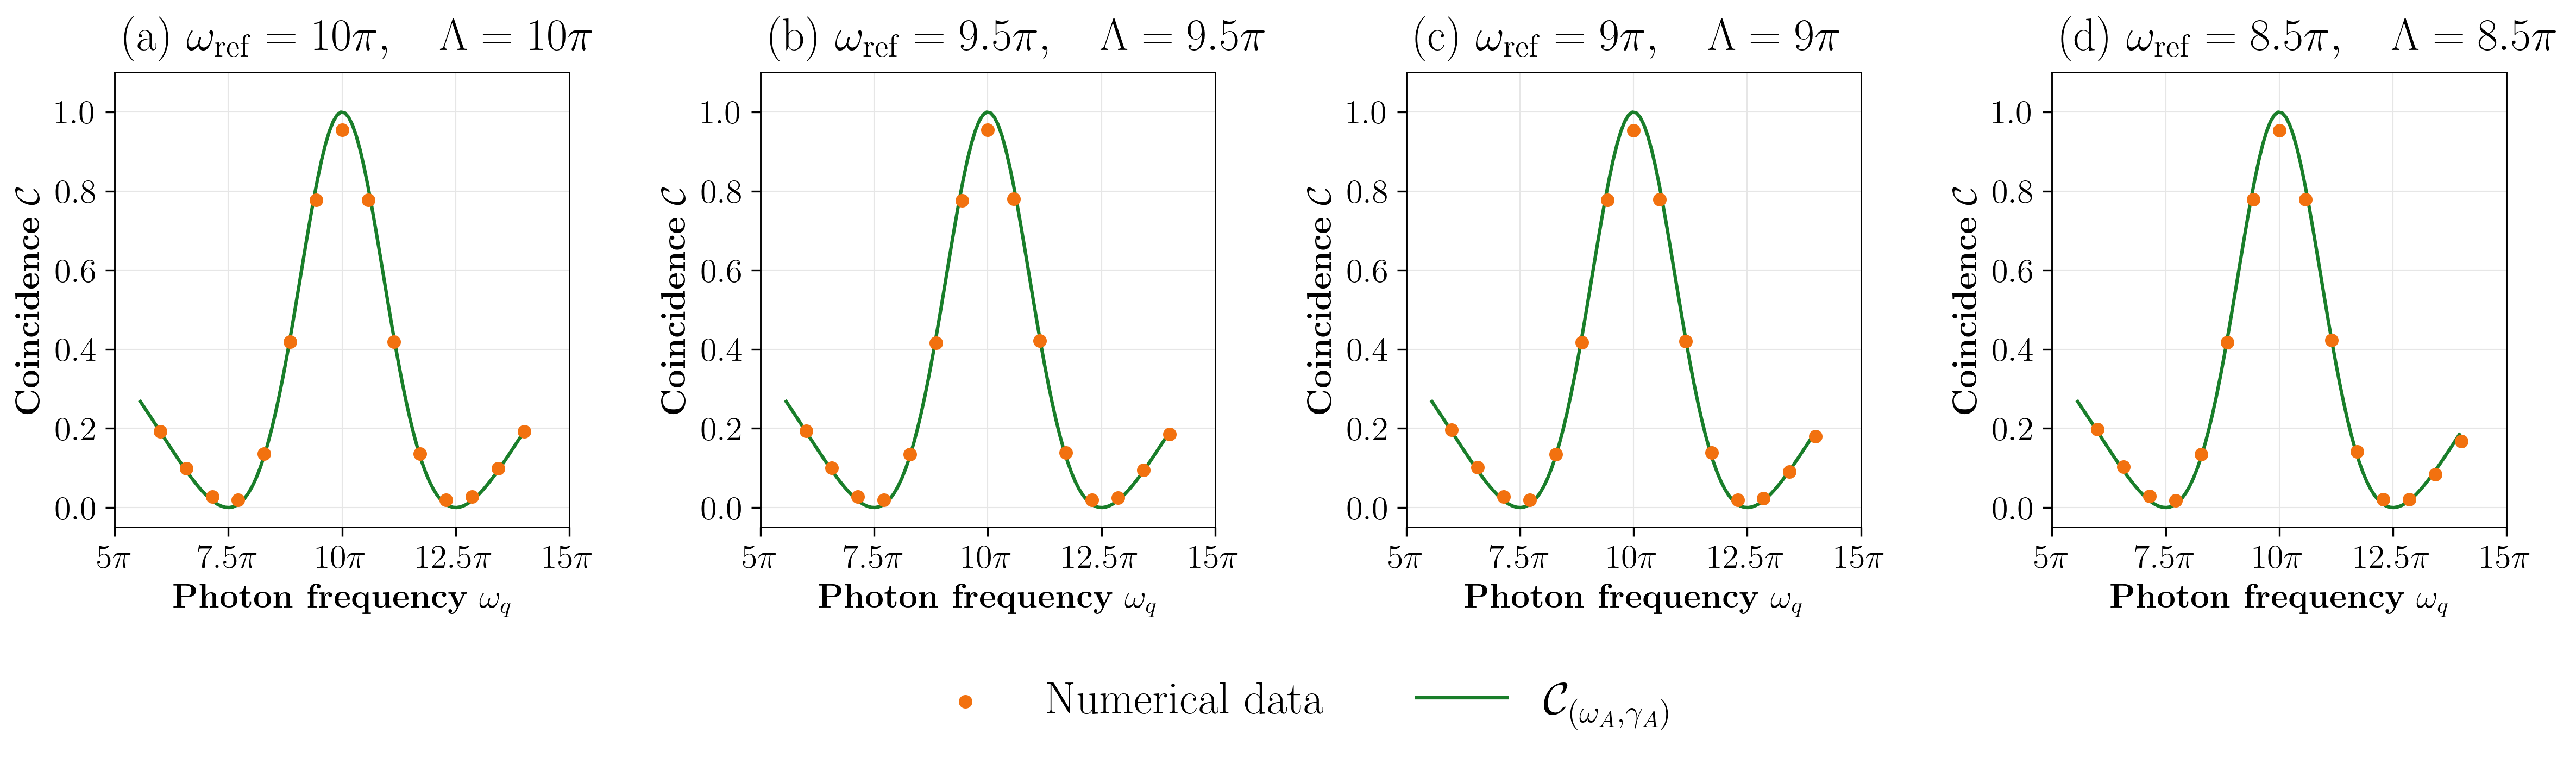

In [7]:
# =========================
# Paramètres
# =========================
index_experiments = [1,2,3,4]

color_atom = "#007013"
color_data = "#f2710f"

subfig_labels = [r'(a) $\omega_{\rm ref} = 10\pi, \quad \Lambda = 10\pi$', 
                 r'(b) $\omega_{\rm ref} = 9.5\pi, \quad \Lambda = 9.5\pi$',
                 r'(c) $\omega_{\rm ref} = 9\pi, \quad \Lambda = 9\pi$',
                 r'(d) $\omega_{\rm ref} = 8.5\pi, \quad \Lambda = 8.5\pi$']

# =========================
# Figure
# =========================
fig, axs = plt.subplots(1,4, figsize=(16,4), dpi=300, sharex=False)
axs = axs.flat

# =========================
# Boucle expériences
# =========================
for idx, ax in enumerate(axs):

    index_experiment = index_experiments[idx]

    ir_cutoff = frequency_windows[index_experiment-1][0]
    uv_cutoff = frequency_windows[index_experiment-1][1]

    data_file = f"../results/csv_files/coincidence_vs_frequency_{index_experiment}_corrected.csv"
    df = pd.read_csv(data_file)

    photon_frequency_tab = df['photon_frequency_tab'].to_numpy()
    coincidence_tab = df['final_reflection_tab'].to_numpy()

    frequency_tab_theory = np.linspace(
        param_cavity['omega_0'] - param_cavity['gamma'],
        param_cavity['omega_0'] + param_cavity['gamma'],
        100
    )

    # =========================
    # Theoretical prediction
    # =========================
    R_theory = 1/(1 + ((frequency_tab_theory - omega_A)/(gamma_A/2))**2)
    coincidence_theory = 1 - 4*R_theory*(1-R_theory)


    # =========================
    # Plot
    # =========================

    ax.scatter(
        photon_frequency_tab,
        coincidence_tab,
        color=color_data,
        s=25,
        label="Numerical data",
        zorder=3
    )

    ax.plot(
        frequency_tab_theory,
        coincidence_theory,
        color=color_atom,
        linewidth=1.5,
        alpha=0.9,
        label=r'$\mathcal{C}_{(\omega_A,\gamma_A)}$'
    )

    # =========================
    # Subfigure label
    # =========================
    ax.text(
        0.02,1.05,
        subfig_labels[idx],
        transform=ax.transAxes,
        fontsize=20,
        fontweight='bold'
    )

    # =========================
    # Axes
    # =========================

    ax.set_xlabel(r'\textbf{Photon frequency} $\omega_q$', fontsize=15)

    ax.set_ylabel(r'\textbf{Coincidence} $\mathcal{C}$', fontsize=15)

    ax.set_ylim([-0.05,1.1])

    ax.set_xticks([
        omega_A - gamma_A,
        omega_A - gamma_A/2,
        omega_A,
        omega_A + gamma_A/2,
        omega_A + gamma_A
    ])

    ax.set_xticklabels([r"$5\pi$",r"$7.5\pi$",r"$10\pi$",r"$12.5\pi$",r"$15\pi$"])

    ax.grid(color='0.9', linestyle='-', linewidth=0.5)

    ax.tick_params(axis='both', which='major', length=4, width=0.8)

    for item in (ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(15)


# =========================
# Légende commune
# =========================

handles, labels = axs[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5,0),
    ncol=3,
    frameon=False,
    fontsize=20
)

plt.tight_layout()

plt.savefig(
    "../results/fig/coincidence_vs_frequency_multi_experiment_corrected.pdf",
    bbox_inches="tight",
    pad_inches=0.2
)

plt.show()